# MoTe2 NetKet Workflow

Notebook-style MoTe2 three-band NetKet workflow, structured similarly to `haldane_model.ipynb`.

- Uses the same MoTe2 parameter set as `bloch_ed_mote2_three_orbital.ipynb`
- Supports two ansatz options: `slater` and `slater_x_boseformer`
- Includes a small-cluster interacting ED cross-check against `bloch_ed`


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# If JAX/NetKet was already imported in this kernel, restart kernel before running further cells.


In [2]:
import math
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import netket as nk

from aidan_custom import (
    build_mote2_three_orbital_hamiltonian,
    noninteracting_slater_orbitals_mote2_three_orbital,
)
from aidan_custom.bloch_ed import (
    build_fock_basis,
    build_many_body_hamiltonian_dense,
    build_mote2_three_orbital_lattice_embedding,
    build_mote2_three_orbital_real_space_terms,
)
from aidan_custom.models import (
    LogSlaterBoseFormer,
    LogSlaterDeterminant,
    make_supercell_reciprocal_vectors,
)
from aidan_custom.mote2_three_orbital import (
    MOTE2_A1,
    MOTE2_A2,
    mote2_three_orbital_berry_and_metric_trace,
    mote2_three_orbital_bloch_hamiltonian,
    mote2_three_orbital_reciprocal_vectors,
)
from aidan_custom.geometry import (
    first_bz_hexagon_vertices,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    sample_shortest_representative_bz,
)
from aidan_custom.optimization import (
    exact_manybody_ground_state_energy,
    log_optimization_diagnostics,
)

print("devices:", jax.devices())
print("default_backend:", jax.default_backend())
if jax.default_backend() != "gpu":
    raise RuntimeError(
        f"Expected GPU backend, got {jax.default_backend()!r}. "
        "Set CUDA_VISIBLE_DEVICES and restart kernel."
    )


∣NK⟩ Tip: Prefer the new nk.driver.VMC_SR over VMC which supports minSR and SPRING.

devices: [CudaDevice(id=0)]
default_backend: gpu


In [3]:
# single particle parameters

# Eq. (2) parameters from Fig. 3b at theta = 3 deg (meV)
# delta = 27.9
# ez = 0.0
# t_th1 = 5.15
# t_hh1 = 1.81
# t_th2 = 0.07
# t_hh3 = 0.43
# t_tt1 = -0.46
# a_m = 1.0
# ph_conj = True

# Ideal-band optimized parameters (same as bloch_ed_mote2_three_orbital.ipynb)
delta = 5.426542963374432
ez = 0.0
t_th1 = 1.0
t_hh1 = 0.4689334070165771
t_th2 = -0.07151471515876148
t_hh3 = 0.037340187144172164
t_tt1 = -0.0377535889269079
a_m = 1.0
ph_conj = True


In [23]:
# many-body system parameters (matching bloch_ed_mote2_three_orbital.ipynb)
Lx = 3
Ly = 3
n_particles = 3
n_fermions = n_particles
V1 = 1.0

params = {
    "Lx": Lx,
    "Ly": Ly,
    "n_fermions": n_fermions,
    "delta": delta,
    "ez": ez,
    "t_th1": t_th1,
    "t_hh1": t_hh1,
    "t_th2": t_th2,
    "t_hh3": t_hh3,
    "t_tt1": t_tt1,
    "a_m": a_m,
    "ph_conj": ph_conj,
    "V1": V1,
}

print(params)


{'Lx': 3, 'Ly': 3, 'n_fermions': 3, 'delta': 5.426542963374432, 'ez': 0.0, 't_th1': 1.0, 't_hh1': 0.4689334070165771, 't_th2': -0.07151471515876148, 't_hh3': 0.037340187144172164, 't_tt1': -0.0377535889269079, 'a_m': 1.0, 'ph_conj': True, 'V1': 1.0}


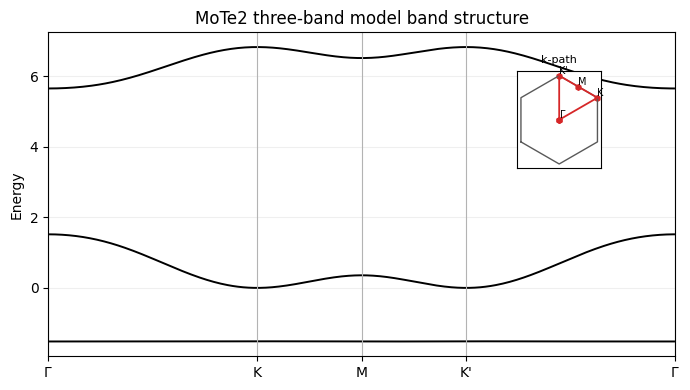

K point = [3.62759873, 2.09439510]
Berry curvature at K (lowest band): -0.34107241
Trace of quantum metric at K (lowest band): 0.34107241
Estimated Chern number (lowest band, coarse mesh): -1.000000


In [24]:
# single-particle diagnostics
b1, b2 = mote2_three_orbital_reciprocal_vectors(a_m=a_m)

k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array(
    [
        np.linalg.eigvalsh(
            mote2_three_orbital_bloch_hamiltonian(
                kx=float(kx),
                ky=float(ky),
                delta=delta,
                ez=ez,
                t_th1=t_th1,
                t_hh1=t_hh1,
                t_th2=t_th2,
                t_hh3=t_hh3,
                t_tt1=t_tt1,
                a_m=a_m,
                ph_conj=ph_conj,
            )
        )
        for kx, ky in k_points
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black", lw=1.4)
ax.plot(x, bands[:, 1], color="black", lw=1.4)
ax.plot(x, bands[:, 2], color="black", lw=1.4)
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("MoTe2 three-band model band structure")
ax.grid(axis="y", alpha=0.2)

# inset BZ path
gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
bz_hex = first_bz_hexagon_vertices(b1, b2)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])

ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()

omega_K, tr_g_K = mote2_three_orbital_berry_and_metric_trace(
    k_node[0],
    k_node[1],
    band="lowest",
    delta=delta,
    ez=ez,
    t_th1=t_th1,
    t_hh1=t_hh1,
    t_th2=t_th2,
    t_hh3=t_hh3,
    t_tt1=t_tt1,
    a_m=a_m,
    ph_conj=ph_conj,
)
print(f"K point = [{k_node[0]:.8f}, {k_node[1]:.8f}]")
print(f"Berry curvature at K (lowest band): {omega_K:.8f}")
print(f"Trace of quantum metric at K (lowest band): {tr_g_K:.8f}")

# quick BZ integral estimate for Chern number on lowest band
Lx_bz_plot = 21
Ly_bz_plot = 21
k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False)
berry_vals = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    berry_vals[i], _ = mote2_three_orbital_berry_and_metric_trace(
        kx,
        ky,
        band="lowest",
        delta=delta,
        ez=ez,
        t_th1=t_th1,
        t_hh1=t_hh1,
        t_th2=t_th2,
        t_hh3=t_hh3,
        t_tt1=t_tt1,
        a_m=a_m,
        ph_conj=ph_conj,
    )
area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
chern_est = (area_bz / (2.0 * np.pi * Lx_bz_plot * Ly_bz_plot)) * np.sum(berry_vals)
print(f"Estimated Chern number (lowest band, coarse mesh): {chern_est:.6f}")


In [25]:
# many-body Hamiltonian setup in NetKet
graph, hi, ham = build_mote2_three_orbital_hamiltonian(**params)
ham_sr = ham.to_fermionoperator2nd()

assert n_fermions <= graph.n_nodes
print(f"n_sites={graph.n_nodes}, n_fermions={hi.n_fermions}")
print(f"hilbert={hi}")
print(f"V1={V1}")
print(f"max_conn_size={ham.max_conn_size}")


n_sites=27, n_fermions=3
hilbert=SpinOrbitalFermions(n_orbitals=27, n_fermions=3)
V1=1.0
max_conn_size=55


Sampling dictionary:

- `n_chains`: number of independent Markov chains evolved in parallel (global across devices)
- `sweep_size`: number of Metropolis proposal/accept steps between recorded samples
- `n_samples`: total kept samples returned by `MCState.sample(...)`
- `n_discard_per_chain`: burn-in samples discarded at each chain start


In [33]:
# optimization controls + model selection
model_type = "slater_x_boseformer"  # options: "slater", "slater_x_boseformer"

n_iter = 100
n_samples = 1024 * 5
n_discard_per_chain = 64
sweep_size = 2 * n_fermions
n_chains = 256
sample_type = "FullSum"  # options: "MC", "FullSum"

# BoseFormer controls (used only for model_type == "slater_x_boseformer")
boseformer_num_layers = 2
boseformer_d_model = 32
boseformer_n_heads = 2
boseformer_mlp_hidden_factor = 2

slater_init_mode = "random"  # options: "random", "noninteracting"
diag_shift = 0.001


def _hashable_matrix(matrix: np.ndarray) -> tuple[tuple[float, ...], ...]:
    # Written with Codex 02-20-26.
    arr = np.asarray(matrix, dtype=np.float64)
    return tuple(tuple(float(v) for v in row) for row in arr.tolist())


def _mote2_site_positions(Lx: int, Ly: int, a_m: float) -> np.ndarray:
    # Written with Codex 02-20-26.
    lattice = build_mote2_three_orbital_lattice_embedding(Lx=Lx, Ly=Ly)
    n_sites = int(Lx) * int(Ly) * int(lattice.n_orbitals_per_cell)

    a1 = float(a_m) * np.asarray(MOTE2_A1, dtype=np.float64)
    a2 = float(a_m) * np.asarray(MOTE2_A2, dtype=np.float64)
    u0 = np.asarray([float(a_m) / np.sqrt(3.0), 0.0], dtype=np.float64)
    offsets = np.asarray([u0, np.zeros(2), -u0], dtype=np.float64)

    positions = np.empty((n_sites, 2), dtype=np.float64)
    for site in range(n_sites):
        x, y, orb = lattice.site_to_cell[site]
        positions[site] = float(x) * a1 + float(y) * a2 + offsets[int(orb)]
    return positions


slater_initial_m_orbitals = None
if slater_init_mode == "noninteracting":
    slater_initial_m_orbitals = noninteracting_slater_orbitals_mote2_three_orbital(
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
        delta=delta,
        ez=ez,
        t_th1=t_th1,
        t_hh1=t_hh1,
        t_th2=t_th2,
        t_hh3=t_hh3,
        t_tt1=t_tt1,
        a_m=a_m,
        ph_conj=ph_conj,
    )
elif slater_init_mode != "random":
    raise ValueError(f"Unknown slater_init_mode={slater_init_mode!r}")

if model_type == "slater":
    model = LogSlaterDeterminant(
        hilbert=hi,
        param_dtype=jnp.float64,
        split_complex_params=True,
        initial_m_orbitals=slater_initial_m_orbitals,
    )
elif model_type == "slater_x_boseformer":
    positions = _mote2_site_positions(Lx=Lx, Ly=Ly, a_m=a_m)
    basis_vectors = np.stack(
        [
            float(a_m) * np.asarray(MOTE2_A1, dtype=np.float64),
            float(a_m) * np.asarray(MOTE2_A2, dtype=np.float64),
        ],
        axis=0,
    )
    g_vectors = np.asarray(
        make_supercell_reciprocal_vectors(
            basis_vectors=basis_vectors,
            Lx=Lx,
            Ly=Ly,
        ),
        dtype=np.float64,
    )

    model = LogSlaterBoseFormer(
        hilbert=hi,
        positions=_hashable_matrix(positions),
        g_vectors=_hashable_matrix(g_vectors),
        num_layers=boseformer_num_layers,
        d_model=boseformer_d_model,
        n_heads=boseformer_n_heads,
        mlp_hidden_factor=boseformer_mlp_hidden_factor,
        slater_param_dtype=jnp.float64,
        slater_initial_m_orbitals=slater_initial_m_orbitals,
        boseformer_param_dtype=jnp.float64,
    )
else:
    raise ValueError(f"Unknown model_type={model_type!r}")

sampler = nk.sampler.MetropolisFermionHop(
    hi,
    graph=graph,
    n_chains=n_chains,
    sweep_size=sweep_size,
)

# if sample_type == "MC":
#     vstate = nk.vqs.MCState(
#         sampler,
#         model,
#         n_samples=n_samples,
#         n_discard_per_chain=n_discard_per_chain,
#     )
# elif sample_type == "FullSum":
#     vstate = nk.vqs.FullSumState(hi, model)
# else:
#     raise ValueError(f"Unknown sample_type={sample_type!r}")

optimizer = nk.optimizer.Sgd(
    learning_rate=optax.linear_schedule(0.05, 0.01, n_iter)
)

driver = nk.driver.VMC_SR(
    ham_sr,
    optimizer,
    variational_state=vstate,
    diag_shift=diag_shift,
    mode="complex",
)

log = nk.logging.RuntimeLog()
driver.run(n_iter=n_iter, out=log, callback=log_optimization_diagnostics)


  0%|          | 0/100 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['Energy', 'UpdateNormL2'],)

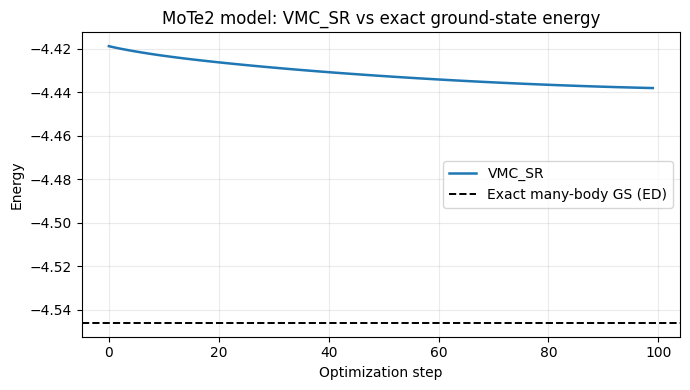

reference method: ED (interacting)
Final VMC_SR energy (real part) = -4.4380757210
Exact ground-state energy = -4.5460690870
Absolute error = 1.080e-01


In [34]:
# plot optimization data
energy_history = log.data["Energy"]
iters = np.asarray(energy_history.iters)
energy_mean = np.asarray(energy_history["Mean"])
energy_sigma = np.asarray(energy_history["Sigma"])
energy_variance = np.asarray(energy_history["Variance"])

energy_std_local = np.sqrt(np.maximum(np.real(energy_variance), 0.0))
energy_tau = np.asarray(energy_history["TauCorr"])
energy_rhat = np.asarray(energy_history["R_hat"])

update_norm_history = log.data.get("UpdateNormL2", None)
update_norm_iters = np.asarray(update_norm_history.iters) if update_norm_history is not None else None
update_norm_values = np.asarray(update_norm_history) if update_norm_history is not None else None

# Exact reference: optional for large Hilbert spaces.
reference_dim_cutoff = 100_000
hilbert_dim_comb = math.comb(int(hi.n_orbitals), int(hi.n_fermions))
compute_reference = hilbert_dim_comb <= reference_dim_cutoff

if compute_reference:
    e_ref = exact_manybody_ground_state_energy(ham)
    e_ref_plot_label = "Exact many-body GS (ED)"
    e_ref_method = "ED (interacting)"
else:
    e_ref = None
    e_ref_plot_label = None
    e_ref_method = (
        f"skipped (C(n_sites,n_fermions)={hilbert_dim_comb} > {reference_dim_cutoff})"
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, np.real(energy_mean), lw=1.8, color="tab:blue", label="VMC_SR")
ax.fill_between(
    iters,
    np.real(energy_mean - energy_sigma),
    np.real(energy_mean + energy_sigma),
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
)
if e_ref is not None:
    ax.axhline(e_ref, color="black", linestyle="--", linewidth=1.4, label=e_ref_plot_label)
    ax.set_title("MoTe2 model: VMC_SR vs exact ground-state energy")
else:
    ax.set_title("MoTe2 model: VMC_SR energy")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

print(f"reference method: {e_ref_method}")
print(f"Final VMC_SR energy (real part) = {np.real(energy_mean[-1]):.10f}")
if e_ref is not None:
    print(f"Exact ground-state energy = {e_ref:.10f}")
    print(f"Absolute error = {abs(np.real(energy_mean[-1]) - e_ref):.3e}")


In [29]:
# small-cluster interacting ED cross-check against bloch_ed
validate_against_bloch_ed = True

if validate_against_bloch_ed:
    val_Lx, val_Ly, val_nf = 1, 2, 2

    val_params = {
        "Lx": val_Lx,
        "Ly": val_Ly,
        "n_fermions": val_nf,
        "delta": delta,
        "ez": ez,
        "t_th1": t_th1,
        "t_hh1": t_hh1,
        "t_th2": t_th2,
        "t_hh3": t_hh3,
        "t_tt1": t_tt1,
        "a_m": a_m,
        "ph_conj": ph_conj,
        "V1": V1,
    }

    _, _, ham_val = build_mote2_three_orbital_hamiltonian(**val_params)
    e_nk_val = float(
        np.real(np.asarray(nk.exact.lanczos_ed(ham_val, k=1, compute_eigenvectors=False)).ravel()[0])
    )

    _, one_body_rs, site_terms = build_mote2_three_orbital_real_space_terms(
        Lx=val_Lx,
        Ly=val_Ly,
        delta=delta,
        ez=ez,
        t_th1=t_th1,
        t_hh1=t_hh1,
        t_th2=t_th2,
        t_hh3=t_hh3,
        t_tt1=t_tt1,
        a_m=a_m,
        ph_conj=ph_conj,
        V1=V1,
    )

    n_sites_val = int(one_body_rs.shape[0])
    two_body = np.zeros((n_sites_val, n_sites_val, n_sites_val, n_sites_val), dtype=np.complex128)
    for i in range(int(site_terms.coefficients.size)):
        a = int(site_terms.create_1[i])
        b = int(site_terms.create_2[i])
        c = int(site_terms.annihilate_1[i])
        d = int(site_terms.annihilate_2[i])
        two_body[a, b, c, d] += np.complex128(site_terms.coefficients[i])

    basis = build_fock_basis(n_orbitals=n_sites_val, n_particles=val_nf)
    h_dense = build_many_body_hamiltonian_dense(
        one_body=one_body_rs,
        two_body=two_body,
        basis=basis,
        cutoff=1e-12,
        hermitize=True,
    )
    e_bloch_val = float(np.linalg.eigvalsh(h_dense)[0].real)

    diff = abs(e_nk_val - e_bloch_val)
    print(f"Validation cluster: Lx={val_Lx}, Ly={val_Ly}, n_fermions={val_nf}")
    print(f"NetKet ED GS energy = {e_nk_val:.16f}")
    print(f"bloch_ed GS energy = {e_bloch_val:.16f}")
    print(f"|difference| = {diff:.3e}")

    tol = 1e-10
    if diff > tol:
        raise AssertionError(f"NetKet vs bloch_ed mismatch above {tol}: {diff}")


Validation cluster: Lx=1, Ly=2, n_fermions=2
NetKet ED GS energy = -2.9091439217526935
bloch_ed GS energy = -2.9091439217526869
|difference| = 6.661e-15


In [ ]:
# save compact training + ED summary to results folder
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
job_tag = (
    f"lx{Lx}_ly{Ly}_nf{n_fermions}_"
    f"delta_{delta:.2f}_ez_{ez:.2f}_"
    f"tth1_{t_th1:.2f}_thh1_{t_hh1:.2f}_"
    f"tth2_{t_th2:.2f}_thh3_{t_hh3:.2f}_"
    f"ttt1_{t_tt1:.2f}_V1_{V1:.2f}_{model_type}_{sample_type.lower()}_{timestamp}"
)

job_dir = Path("results/mote2_netket") / job_tag
raw_data_dir = job_dir / "raw_data"
plots_dir = job_dir / "plots_optimization"
raw_data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    raw_data_dir / "optimization_history.npz",
    iters=iters,
    energy_mean=np.asarray(energy_mean),
    energy_sigma=np.asarray(energy_sigma),
    energy_variance=np.asarray(energy_variance),
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, np.real(energy_mean), lw=1.8, color="tab:blue", label="VMC_SR")
if e_ref is not None:
    ax.axhline(e_ref, color="black", ls="--", lw=1.4, label="Exact ED")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.set_title("MoTe2 model optimization")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "energy_vs_step.png", dpi=180)
plt.close(fig)

summary = {
    "parameters": params,
    "model_type": model_type,
    "sample_type": sample_type,
    "n_iter": int(n_iter),
    "final_energy_real": float(np.real(energy_mean[-1])),
    "reference_method": e_ref_method,
    "reference_energy": None if e_ref is None else float(e_ref),
}

(job_dir / "summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
log.serialize(job_dir / "runtime_log")

print(f"Saved notebook outputs to {job_dir}")
